# PJ14 — 성남시 뉴스 크롤링 & 공공 문제 키워드 분석

**목표:** 2년치 네이버 뉴스(19,472건)에서 성남시의 주요 공공 문제 키워드 Top 10을 도출하여 차기 프로젝트(PJ15) 주제를 선정한다.

```
[Step 0] 환경 설정 및 데이터 경로 설정
[Step 1] 데이터 로드 및 전처리
[Step 2] 문제 지시어 필터링
[Step 3] 형태소 분석 (KoNLPy Okt)
[Step 4] BERTopic 토픽 모델링
[Step 5] 문제 키워드 Top 10 도출 및 주제 선정
```

---
## Step 0 — 환경 설정

In [194]:
import glob
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from wordcloud import WordCloud

warnings.filterwarnings("ignore")

# 한글 폰트 설정 (Windows)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 출력 디렉토리
OUTPUT_DIR = Path("output")

# output/ 내 가장 최근 CSV 자동 선택
csv_files = sorted(OUTPUT_DIR.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError("output/ 디렉토리에 CSV 파일이 없습니다.")
CSV_PATH = csv_files[-1]
print(f"사용할 파일: {CSV_PATH}")

사용할 파일: output\성남시_news_20260405_214958.csv


---
## Step 1 — 데이터 로드 및 전처리

In [195]:
df = pd.read_csv(CSV_PATH, encoding="utf-8-sig", parse_dates=["date"])
print(f"원본 행 수: {len(df):,}건")
df.head(3)

원본 행 수: 19,472건


,keyword,title,press,date,date_str,link,body_preview,crawled_at
0,성남시,"""아직 시간 남았죠?""…경기 투표 마감 1분 전까지 '유권자 행렬'",뉴스1,2024-04-06,2024.04.06.,https://n.news.naver.com/mnews/article/421/000...,"4·10 총선 사전투표 마감…경기도 29.54%, 전국 31.28% 투표율 기록 제...",2026-04-05 21:50:00
1,성남시,경기 사전투표율 최종 29.54%… 21대보다 5.66%p↑,뉴스1,2024-04-06,2024.04.06.,https://n.news.naver.com/mnews/article/421/000...,2년 전 지방선거 때보다는 10.48%p 올라 제22대 국회의원 총선거 사전투표가 ...,2026-04-05 21:50:00
2,성남시,"국힘 고석 ""금·토요일 야간 상업지역 옥외영업 규제 완화""",뉴시스,2024-04-06,2024.04.06.,https://n.news.naver.com/mnews/article/003/001...,수지지역 야간경제특구 추진…경제 활성화·시민 편의 신분당선 열차·광역버스 막차 1시...,2026-04-05 21:50:00


In [196]:
# 중복 제거 (link 기준) + title 공백 행 제거
df = df.drop_duplicates(subset="link").reset_index(drop=True)
df = df[df["title"].str.strip().astype(bool)].reset_index(drop=True)

# body_preview NaN → 빈 문자열
df["body_preview"] = df["body_preview"].fillna("")

# date 파싱 실패 행 제거
df = df.dropna(subset=["date"]).reset_index(drop=True)

print(f"전처리 후 행 수: {len(df):,}건")
print(f"기간: {df['date'].min().date()} ~ {df['date'].max().date()}")

전처리 후 행 수: 19,166건
기간: 2024-04-05 ~ 2026-04-05


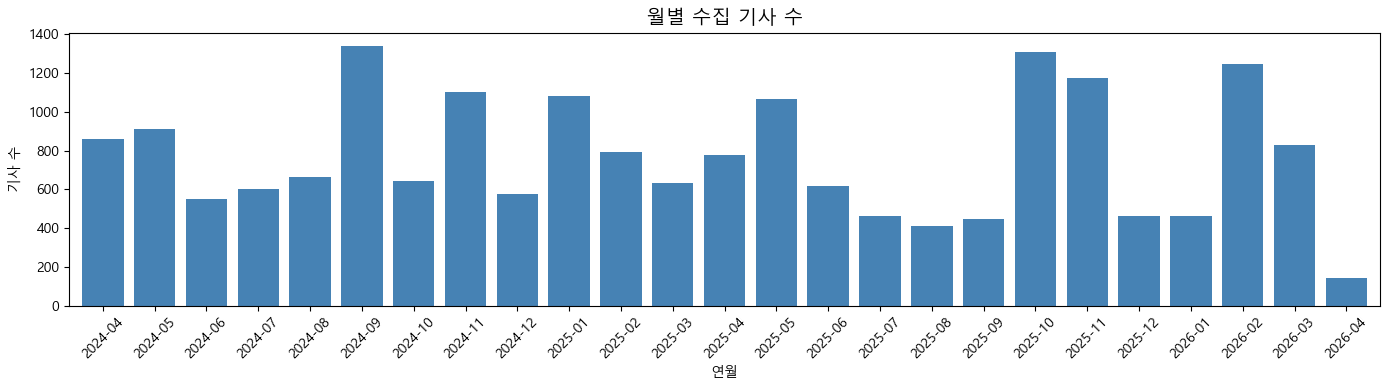

In [197]:
# 연월별 기사 수 시계열 시각화
monthly = df.groupby(df["date"].dt.to_period("M")).size()

fig, ax = plt.subplots(figsize=(14, 4))
monthly.plot(kind="bar", ax=ax, color="steelblue", width=0.8)
ax.set_title("월별 수집 기사 수", fontsize=14)
ax.set_xlabel("연월")
ax.set_ylabel("기사 수")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

---
## Step 2 — 문제 지시어 필터링

In [198]:
문제_지시어 = [
    "민원", "불만", "논란", "갈등", "문제", "부족", "부재",
    "위험", "사고", "미흡", "지연", "적체", "부담", "피해",
    "반발", "충돌", "오염", "결함", "위반", "방치",
]

# 제목 + 본문 미리보기 통합 텍스트 생성
df["text"] = df["title"].str.strip() + " " + df["body_preview"].str.strip()

# 지시어 포함 여부 마스크
pattern = "|".join(문제_지시어)
mask = df["text"].str.contains(pattern, na=False)

df_filtered = df[mask].reset_index(drop=True)

print(f"전체: {len(df):,}건")
print(f"필터링 후: {len(df_filtered):,}건 ({len(df_filtered)/len(df)*100:.1f}%)")

전체: 19,166건
필터링 후: 3,190건 (16.6%)


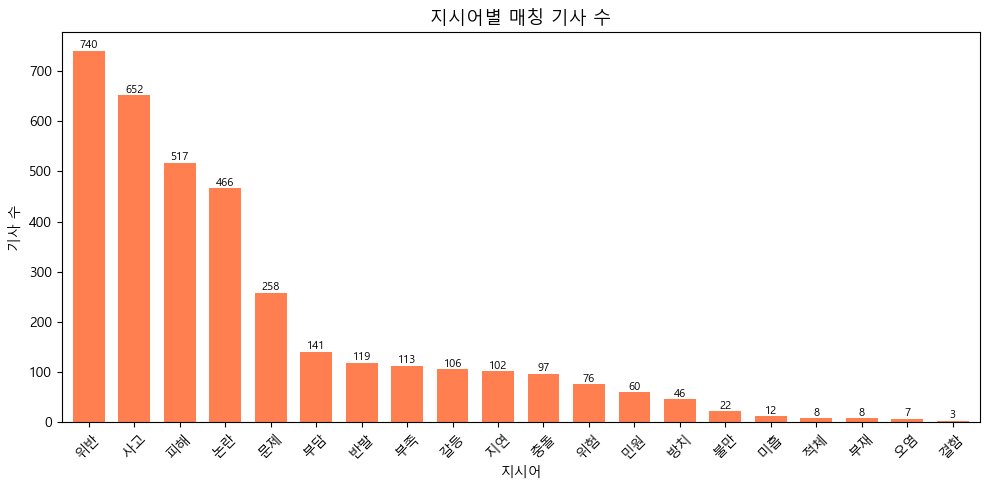

In [199]:
# 지시어별 매칭 빈도 확인
keyword_counts = {
    kw: df["text"].str.contains(kw, na=False).sum()
    for kw in 문제_지시어
}
kw_series = pd.Series(keyword_counts).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
kw_series.plot(kind="bar", ax=ax, color="coral", width=0.7)
ax.set_title("지시어별 매칭 기사 수", fontsize=13)
ax.set_xlabel("지시어")
ax.set_ylabel("기사 수")
ax.tick_params(axis="x", rotation=45)
for i, v in enumerate(kw_series):
    ax.text(i, v + 5, str(v), ha="center", fontsize=8)
plt.tight_layout()
plt.show()

---
## Step 3 — 형태소 분석 (kiwipiepy)

In [200]:
from kiwipiepy import Kiwi

kiwi = Kiwi()

# 불용어 목록
STOPWORDS = {
    "성남시", "성남", "경기", "기자", "뉴스", "시장", "의원",
    "기사", "관련", "통해", "위해", "대해", "지난", "오늘",
    "내용", "것이", "수도", "이번", "지역", "이후", "해당",
}

def extract_nouns(text: str) -> list[str]:
    # NNG: 일반명사, NNP: 고유명사
    tokens = kiwi.tokenize(text)
    return [
        token.form for token in tokens
        if token.tag in ("NNG", "NNP")
        and len(token.form) >= 2
        and token.form not in STOPWORDS
    ]

# 필터링된 기사 전체 명사 추출
tqdm.pandas(desc="형태소 분석")
df_filtered["nouns"] = df_filtered["text"].progress_apply(extract_nouns)

# BERTopic용 토크나이즈 텍스트 (명사 공백 연결)
df_filtered["nouns_text"] = df_filtered["nouns"].apply(lambda x: " ".join(x))

print("형태소 분석 완료")
df_filtered[["title", "nouns"]].head(3)

형태소 분석:   0%|          | 0/3190 [00:00<?, ?it/s]

형태소 분석 완료


,title,nouns
0,“우리가 지면 협력사도 피해” 두산 직원이 美 변호사 자격증을 딴 이...,"[협력사, 두산, 직원, 변호사, 자격증, 두산에너빌리티, 수석, 인터뷰, 수주, ..."
1,사전투표 열기 속 ‘대파 금지’ 논란·투표소 난동 등 사건사고 多 [4·...,"[사전, 투표, 열기, 금지, 논란, 투표소, 난동, 사건, 사고, 전국, 각지, ..."
2,[박정훈 칼럼] 유동규는 왜 ‘목숨 걸고’ 법정에 선다 했나,"[박정훈, 칼럼, 유동, 목숨, 법정, 증인, 거대, 야당, 권력, 자체, 공포, ..."


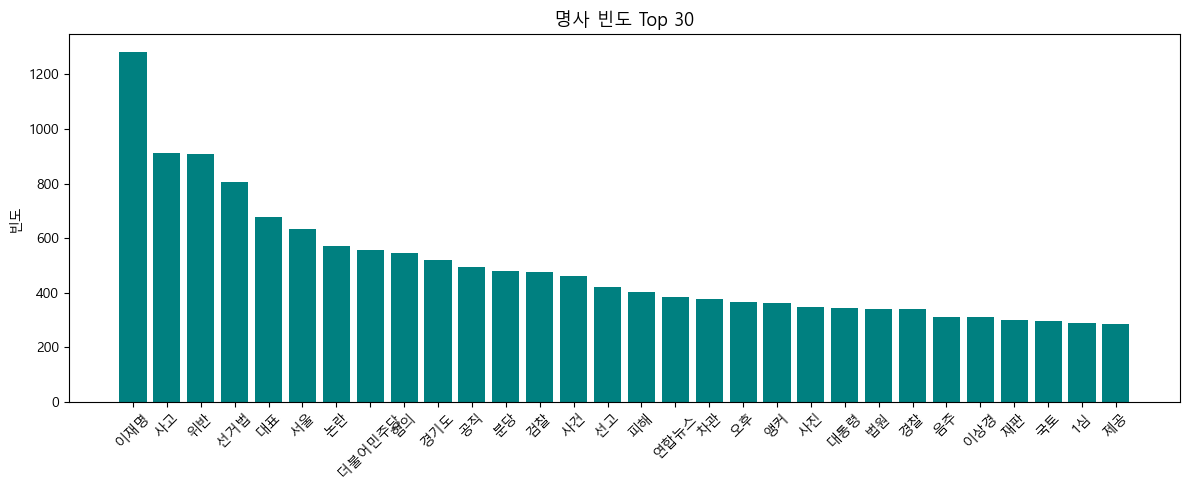

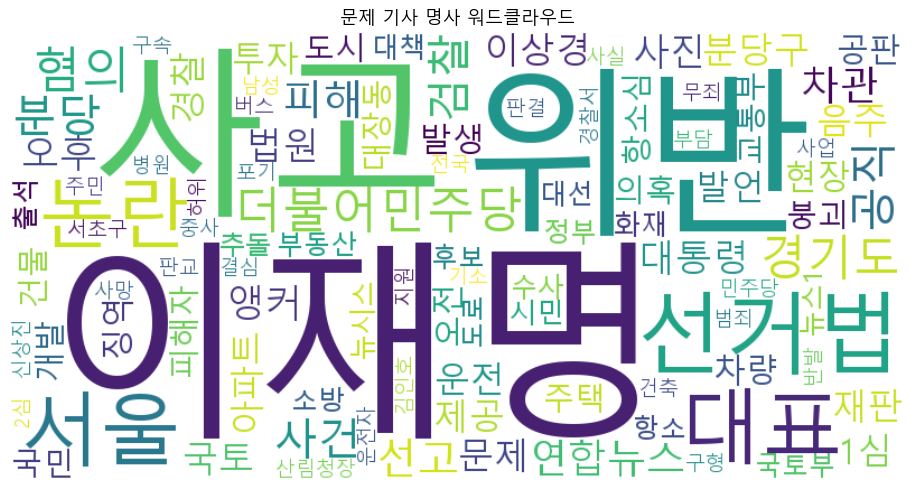

In [201]:
from collections import Counter

# 전체 명사 빈도 집계
all_nouns = [noun for nouns in df_filtered["nouns"] for noun in nouns]
noun_counter = Counter(all_nouns)
top30 = noun_counter.most_common(30)

# 바차트
words, counts = zip(*top30)
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(words, counts, color="teal")
ax.set_title("명사 빈도 Top 30", fontsize=13)
ax.set_ylabel("빈도")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# 워드클라우드
wc = WordCloud(
    font_path="C:/Windows/Fonts/malgun.ttf",
    background_color="white",
    width=800, height=400,
    max_words=100,
).generate_from_frequencies(dict(noun_counter))

fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("문제 기사 명사 워드클라우드", fontsize=13)
plt.tight_layout()
plt.show()

---
## Step 4 — BERTopic 토픽 모델링

In [229]:
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# ▼ N-gram 범위 선택 ▼
# (1, 1) → unigram만     예) "붕괴", "정자교"
# (1, 2) → uni + bigram  예) "붕괴", "정자교", "정자교 붕괴"  ← 권장
# (2, 2) → bigram만      예) "정자교 붕괴", "전공의 파업"
NGRAM_RANGE = (2, 2)

# 임베딩 모델 (한국어)
embedding_model = SentenceTransformer("jhgan/ko-sroberta-multitask")

# 차원 축소
umap_model = UMAP(
    n_components=5,
    n_neighbors=15,
    min_dist=0.0,
    metric="cosine",
    random_state=42,
)

# 클러스터링
hdbscan_model = HDBSCAN(
    min_cluster_size=30,
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
)

# 벡터라이저
vectorizer = CountVectorizer(ngram_range=NGRAM_RANGE)

# BERTopic 모델
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer,
    ctfidf_model=ClassTfidfTransformer(reduce_frequent_words=True),
    nr_topics=20,
    language="korean",
    verbose=True,
)

docs_tokenized = df_filtered["nouns_text"].tolist()

topics, probs = topic_model.fit_transform(docs_tokenized)
print(f"\nN-gram 설정: {NGRAM_RANGE}")
print(f"도출된 토픽 수: {len(set(topics)) - 1}개 (미분류 제외)")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: jhgan/ko-sroberta-multitask
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-06 19:44:38,747 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/100 [00:00<?, ?it/s]

2026-04-06 19:45:10,985 - BERTopic - Embedding - Completed ✓
2026-04-06 19:45:10,986 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-06 19:45:22,033 - BERTopic - Dimensionality - Completed ✓
2026-04-06 19:45:22,035 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-06 19:45:22,095 - BERTopic - Cluster - Completed ✓
2026-04-06 19:45:22,096 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-06 19:45:22,260 - BERTopic - Representation - Completed ✓
2026-04-06 19:45:22,262 - BERTopic - Topic reduction - Reducing number of topics
2026-04-06 19:45:22,283 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-06 19:45:22,426 - BERTopic - Representation - Completed ✓
2026-04-06 19:45:22,429 - BERTopic - Topic reduction - Reduced number of topics from 41 to 20



N-gram 설정: (2, 2)
도출된 토픽 수: 19개 (미분류 제외)


In [231]:
# 토픽별 키워드 및 기사 수 확인
topic_info = topic_model.get_topic_info()
topic_info_filtered = topic_info[topic_info["Topic"] != -1].reset_index(drop=True)

print(f"유효 토픽 수: {len(topic_info_filtered)}개")
topic_info_filtered[["Topic", "Count", "Name"]]

유효 토픽 수: 19개


,Topic,Count,Name
0,0,414,0_선거법 위반_공직 선거법_이재명 더불어민주당_더불어민주당 대표
1,1,278,1_선도 지구_분당 도시_이주 대책_도시 건축
2,2,260,2_추돌 사고_경부고속도로 서울_경기도 소방_서울 요금소
3,3,223,3_항소 포기_윤석열 대통령_비상 대책_대장동 개발
4,4,205,4_흉기 난동_분당 흉기_중고 거래_압수 수색
5,5,203,5_인명 피해_건물 화재_복합 상가_상가 건물
6,6,170,6_이상경 국토_국토 교통부_교통부 차관_투자 논란
7,7,107,7_김현지 대통령실_대통령실 부속실장_국정 감사_개혁 신당
8,8,88,8_출생 문제_현대 희망_희망 재단_사회 문제
9,9,87,9_음주 운전_인도 돌진_의식 불명_음주 뺑소니


In [232]:
# 토픽별 대표 키워드 표
rows = []
for _, row in topic_info_filtered.iterrows():
    topic_id = row["Topic"]
    keywords = [w for w, _ in topic_model.get_topic(topic_id)[:5]]
    rows.append({
        "토픽": topic_id,
        "기사수": row["Count"],
        "대표 키워드": ", ".join(keywords),
    })

df_topics = pd.DataFrame(rows).sort_values("기사수", ascending=False).reset_index(drop=True)
df_topics.head(15)

,토픽,기사수,대표 키워드
0,0,414,"선거법 위반, 공직 선거법, 이재명 더불어민주당, 더불어민주당 대표, 이재명 대표"
1,1,278,"선도 지구, 분당 도시, 이주 대책, 도시 건축, 분당 건축"
2,2,260,"추돌 사고, 경부고속도로 서울, 경기도 소방, 서울 요금소, 재난 본부"
3,3,223,"항소 포기, 윤석열 대통령, 비상 대책, 대장동 개발, 개발 비리"
4,4,205,"흉기 난동, 분당 흉기, 중고 거래, 압수 수색, 정보 유출"
5,5,203,"인명 피해, 건물 화재, 복합 상가, 상가 건물, 성호 건축"
6,6,170,"이상경 국토, 국토 교통부, 교통부 차관, 투자 논란, 논란 이상경"
7,7,107,"김현지 대통령실, 대통령실 부속실장, 국정 감사, 개혁 신당, 국감 출석"
8,8,88,"출생 문제, 현대 희망, 희망 재단, 사회 문제, 재해 피해"
9,9,87,"음주 운전, 인도 돌진, 의식 불명, 음주 뺑소니, 뺑소니 사망"


In [233]:
# 토픽별 대표 기사 + 링크 조회 (get_representative_docs 기반)
# docs_tokenized와 df_filtered를 index로 연결하여 원본 행 역추적

# docs_tokenized → df_filtered 인덱스 매핑용 Series
nouns_to_idx = pd.Series(df_filtered.index, index=df_filtered["nouns_text"].values)

rep_rows = []
for _, row in df_topics.head(15).iterrows():
    topic_id = row["토픽"]
    rep_docs = topic_model.get_representative_docs(topic_id)  # 최대 3건 반환

    for doc in rep_docs[:1]:   # 대표 1건만 사용
        # nouns_text로 원본 행 역추적
        matched = df_filtered[df_filtered["nouns_text"] == doc]
        if matched.empty:
            # 완전 일치 실패 시 첫 글자 50자로 부분 매칭
            matched = df_filtered[df_filtered["nouns_text"].str.startswith(doc[:50])]

        if not matched.empty:
            orig = matched.iloc[0]
            rep_rows.append({
                "토픽": topic_id,
                "대표 키워드": row["대표 키워드"],
                "기사 제목": orig["title"],
                "날짜": str(orig["date"])[:10],
                "언론사": orig["press"],
                "링크": orig["link"],
            })
        else:
            rep_rows.append({
                "토픽": topic_id,
                "대표 키워드": row["대표 키워드"],
                "기사 제목": doc[:40] + "...",
                "날짜": "-",
                "언론사": "-",
                "링크": "-",
            })

df_rep = pd.DataFrame(rep_rows)

# 링크를 클릭 가능한 HTML로 출력
from IPython.display import HTML

def make_link(url):
    if url == "-":
        return "-"
    return f'<a href="{url}" target="_blank">기사 보기</a>'

df_display = df_rep.copy()
df_display["링크"] = df_display["링크"].apply(make_link)
df_display = df_display.drop(columns=["대표 키워드"])

display(HTML(df_display.to_html(escape=False, index=False)))

토픽,기사 제목,날짜,언론사,링크
0,"검찰, 이재명 '공직선거법 위반' 항소심서 징역 2년 구형",2025-02-26,대전일보,기사 보기
1,"성남시, 국토부에 핵심 철도사업 반영·분당 재건축 물량제한 재검토 촉...",2026-02-25,아시아경제,기사 보기
2,가천대역 입간판 강풍에 쓰러지며 마을버스 덮쳐…승객 1명 부상,2024-11-26,연합뉴스,기사 보기
3,[속보] 권익위 “尹대통령 검사시절 ‘한우 업추비’ 위반 아냐…사건 ...,2024-05-13,헤럴드경제,기사 보기
4,"경찰, 네이버·네이트 압수수색…'류희림 민원 사주' 개인정보 유출 수...",2024-10-09,TV조선,기사 보기
5,성남 성호시장 철거 현장서 붕괴사고…40대 근로자 사망(종합),2024-07-16,뉴스1,기사 보기
6,'갭투자 논란' 이상경 국토교통부 1차관 사의 표명,2025-10-24,SBS,기사 보기
7,"경찰, '성희롱 발언' 민주당 현근택 검찰 송치 예정",2024-04-09,연합뉴스,기사 보기
8,"▶우리나라에서도 대구 달서구,성남시, 김해시 등이 남녀 만남을 주선하는 프로그램을 운영 중이다. 지자체가 참가자를 간단하게나마 검증해주는 점이 장점이다. 프로그램 이름도 각각 ‘고고(만나go 결혼하go) 미팅’, ‘솔로몬(SOLO MON)의 선택’, ‘나는 김해솔로’ 등으로 재미가 있다. 어떤 지자체는...",2024-07-07,조선일보,기사 보기
9,음주 뺑소니 사망사고 내고 ‘술타기’ 시도한 20대 송치,2024-11-13,KBS,기사 보기


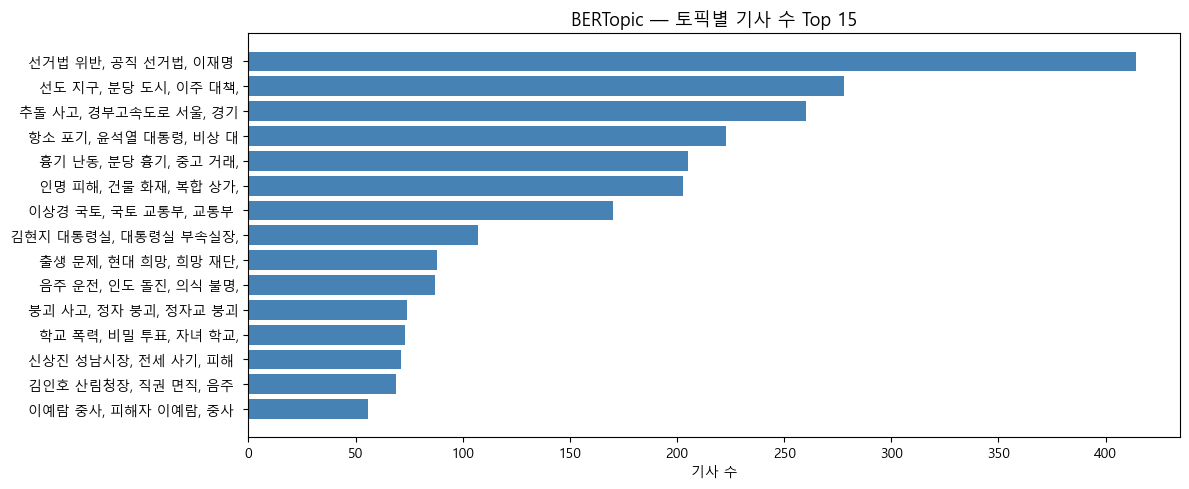

In [234]:
# 토픽별 기사 수 바차트 (Top 15)
top15 = df_topics.head(15)
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(
    top15["대표 키워드"].str[:20],
    top15["기사수"],
    color="steelblue"
)
ax.invert_yaxis()
ax.set_title("BERTopic — 토픽별 기사 수 Top 15", fontsize=13)
ax.set_xlabel("기사 수")
plt.tight_layout()
plt.show()

### 토픽 분류 품질 시각화

In [235]:
# [시각화 1] 인터토픽 거리 맵 — 토픽 간 거리와 크기를 2D로 표현
# 원이 멀수록 토픽 간 의미 차이가 큼, 원이 클수록 기사 수가 많음
fig = topic_model.visualize_topics(title="인터토픽 거리 맵")
fig.show()

In [236]:
# [시각화 2] 문서 클러스터 맵 — 실제 기사들이 2D 공간에서 어떻게 군집되었는지
# 색상이 같은 점들이 같은 토픽으로 분류된 기사들
# 점들이 명확히 분리되어 있을수록 토픽 분류가 잘 된 것
fig = topic_model.visualize_documents(
    docs_tokenized,
    title="문서 클러스터 맵",
    hide_annotations=True,   # 토픽 레이블 숨김 (점이 너무 많아 가독성 저하 방지)
)
fig.show()

In [237]:
# [시각화 3] 토픽 유사도 히트맵 — 토픽 간 코사인 유사도
# 대각선(자기 자신)이 가장 진하고, 비슷한 토픽끼리 밝게 표시됨
# 특정 두 토픽이 밝으면 중복 키워드가 많다는 의미 → 합산 가능성 검토
fig = topic_model.visualize_heatmap(title="토픽 유사도 히트맵")
fig.show()

In [238]:
# 시계열 토픽 분포 (topics_over_time)
timestamps = df_filtered["date"].dt.to_pydatetime().tolist()

topics_over_time = topic_model.topics_over_time(
    docs_tokenized,
    timestamps,
    nr_bins=24,   # 월별 수준 (2년 = 약 24개 구간)
    global_tuning=True,
)

# 상위 10개 토픽만 시각화
top10_ids = df_topics["토픽"].head(10).tolist()
fig = topic_model.visualize_topics_over_time(
    topics_over_time,
    topics=top10_ids,
    title="토픽 시계열 분포 (Top 10)",
)
fig.show()

24it [00:01, 17.50it/s]


---
## Step 5 — 문제 키워드 Top 10 도출 및 PJ15 주제 선정

In [218]:
# 전체 토픽 표 출력 — 정치성 토픽 번호 파악용
# 이 표를 보고 아래 셀의 정치_제외_토픽 리스트를 직접 수정하세요.
print(df_topics.reset_index(drop=True)[["토픽", "기사수", "대표 키워드"]])

    토픽  기사수                                          대표 키워드
0    0  478  이재명 선거법, 이재명 더불어민주당, 공직 선거법, 더불어민주당 대표, 선거법 위반
1    1  327         경부고속도로 서울, 추돌 사고, 서울 요금소, 서울 방향, 요금소 부근
2    2  265              붕괴 사고, 인명 피해, 정자 붕괴, 건물 화재, 정자교 붕괴
3    3  175           이상경 국토, 교통부 차관, 투자 논란, 논란 이상경, 국토 교통부
4    4  174              선도 지구, 분당 도시, 서울 아파트, 분당 건축, 도시 건축
5    5  120              항소 포기, 포기 논란, 대장동 개발, 개발 비리, 민간 업자
6    6   67       김인호 산림청장, 직권 면직, 산림청장 음주, 면직 김인호, 산림청장 직권
7    7   56               정보 유출, 방송 통신, 개인 정보, 통신 심의, 압수 수색
8    8   55     이예람 중사, 피해자 이예람, 중사 영결식, 분당구 국군수도병원, 공군 성폭력
9    9   50             사랑 상품권, 석유 관리원, 취소 고민, 중동 정세, 결제 모습
10  10   49         신상진 성남시장, 현장 민원실, 민원 발급기, 무인 민원, 문자 서비스
11  11   48      김현지 대통령실, 대통령실 부속실장, 국정 감사, 국감 출석, 대통령 김현지
12  12   37              학교 폭력, 자녀 학교, 가해 학생, 자녀 논란, 폭력 가해자
13  13   37           중증 질환자, 소득 중증, 이준석 이재명, 공공 의료, 공공 의료원
14  14   36               문제 유출, 시험 문제, 유출 의혹, 의혹 경찰, 경찰 수사
15  15   33            공직자 범죄, 처장 후보자, 수

In [240]:
# ▼ 위 표를 보고 정치성 토픽 번호를 직접 입력하세요 ▼
정치_제외_토픽 = [0, 3, 6, 7, 13, 14, 15, 16, 18]
df_topics_시민 = (
    df_topics[~df_topics["토픽"].isin(정치_제외_토픽)]
    .reset_index(drop=True)
)

print(f"전체 토픽: {len(df_topics)}개 → 정치 제외 후: {len(df_topics_시민)}개")
df_topics_시민[["토픽", "기사수", "대표 키워드"]]

전체 토픽: 19개 → 정치 제외 후: 10개


,토픽,기사수,대표 키워드
0,1,278,"선도 지구, 분당 도시, 이주 대책, 도시 건축, 분당 건축"
1,2,260,"추돌 사고, 경부고속도로 서울, 경기도 소방, 서울 요금소, 재난 본부"
2,4,205,"흉기 난동, 분당 흉기, 중고 거래, 압수 수색, 정보 유출"
3,5,203,"인명 피해, 건물 화재, 복합 상가, 상가 건물, 성호 건축"
4,8,88,"출생 문제, 현대 희망, 희망 재단, 사회 문제, 재해 피해"
5,9,87,"음주 운전, 인도 돌진, 의식 불명, 음주 뺑소니, 뺑소니 사망"
6,10,74,"붕괴 사고, 정자 붕괴, 정자교 붕괴, 분당 정자교, 공무원 구속"
7,11,73,"학교 폭력, 비밀 투표, 자녀 학교, 의장 선거, 자녀 논란"
8,12,71,"신상진 성남시장, 전세 사기, 피해 예방, 주택 임대차, 현장 민원실"
9,17,40,"을지 연습, 국정 자원, 리튬 이온, 지하 공간, 대피 통제"


In [241]:
# 시민 생활 토픽 Top 10 정리 표
top10 = df_topics_시민.head(10).copy()
top10.index = range(1, len(top10) + 1)
top10.index.name = "순위"

def get_peak_month(topic_id: int) -> str:
    subset = topics_over_time[topics_over_time["Topic"] == topic_id]
    if subset.empty:
        return "-"
    peak_row = subset.loc[subset["Frequency"].idxmax()]
    return str(peak_row["Timestamp"])[:7]

top10["피크 월"] = top10["토픽"].apply(get_peak_month)

print("=" * 60)
print("성남시 공공 문제 키워드 Top 10 (정치 토픽 제외)")
print("=" * 60)
display(top10[["기사수", "대표 키워드", "피크 월"]])

성남시 공공 문제 키워드 Top 10 (정치 토픽 제외)


,기사수,대표 키워드,피크 월
순위,,,
1,278,"선도 지구, 분당 도시, 이주 대책, 도시 건축, 분당 건축",2026-02
2,260,"추돌 사고, 경부고속도로 서울, 경기도 소방, 서울 요금소, 재난 본부",2024-11
3,205,"흉기 난동, 분당 흉기, 중고 거래, 압수 수색, 정보 유출",2026-02
4,203,"인명 피해, 건물 화재, 복합 상가, 상가 건물, 성호 건축",2024-11
5,88,"출생 문제, 현대 희망, 희망 재단, 사회 문제, 재해 피해",2025-05
6,87,"음주 운전, 인도 돌진, 의식 불명, 음주 뺑소니, 뺑소니 사망",2024-11
7,74,"붕괴 사고, 정자 붕괴, 정자교 붕괴, 분당 정자교, 공무원 구속",2024-04
8,73,"학교 폭력, 비밀 투표, 자녀 학교, 의장 선거, 자녀 논란",2024-10
9,71,"신상진 성남시장, 전세 사기, 피해 예방, 주택 임대차, 현장 민원실",2024-05


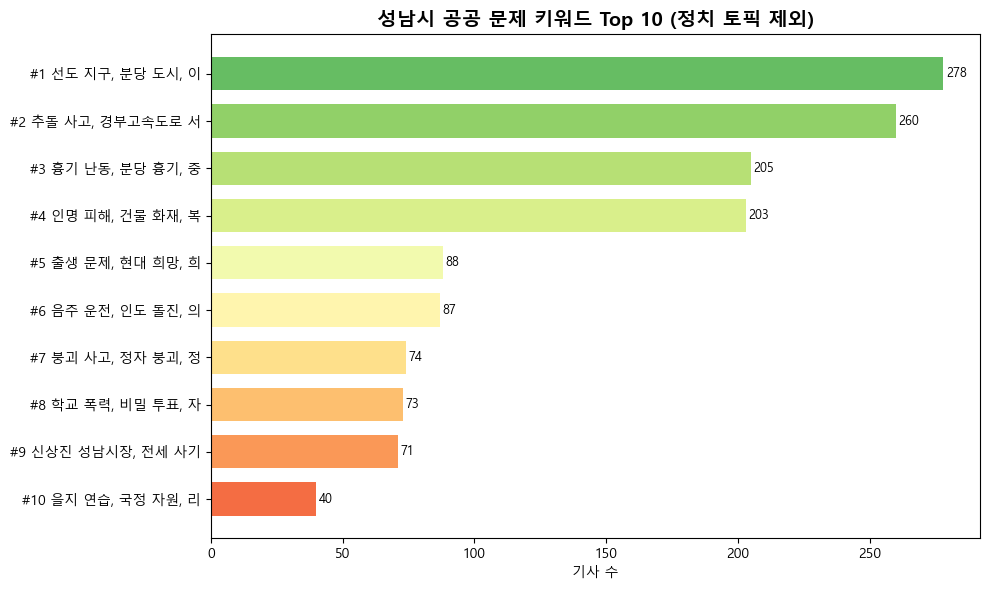

In [242]:
# 시민 생활 토픽 Top 10 바차트
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(top10)))
bars = ax.barh(
    range(len(top10), 0, -1),
    top10["기사수"].values,
    color=colors,
    height=0.7,
)
ax.set_yticks(range(len(top10), 0, -1))
ax.set_yticklabels(
    [f"#{i} {row['대표 키워드'][:15]}" for i, (_, row) in enumerate(top10.iterrows(), 1)],
    fontsize=10,
)
ax.set_xlabel("기사 수")
ax.set_title("성남시 공공 문제 키워드 Top 10 (정치 토픽 제외)", fontsize=14, fontweight="bold")
for bar, count in zip(bars, top10["기사수"].values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            str(count), va="center", fontsize=9)
plt.tight_layout()
plt.show()

In [243]:
# 시민 생활 Top 5 토픽 전체 키워드 목록 조회
from IPython.display import display

for rank, (_, row) in enumerate(df_topics_시민.head(5).iterrows(), start=1):
    topic_id = row["토픽"]
    keywords = topic_model.get_topic(topic_id)
    df_kw = pd.DataFrame(keywords, columns=["키워드", "점수"]).round({"점수": 4})
    print(f"{'='*50}")
    print(f"[{rank}순위] 토픽 {topic_id} — {row['대표 키워드']} ({row['기사수']}건)")
    print(f"{'='*50}")
    display(df_kw)

[1순위] 토픽 1 — 선도 지구, 분당 도시, 이주 대책, 도시 건축, 분당 건축 (278건)


,키워드,점수
0,선도 지구,0.3675
1,분당 도시,0.3024
2,이주 대책,0.2940
3,도시 건축,0.2701
4,분당 건축,0.2655
5,공공 기여,0.2557
6,도시 선도,0.2505
7,서울 아파트,0.2505
8,도시 이주,0.2450
9,분양 전환,0.2391


[2순위] 토픽 2 — 추돌 사고, 경부고속도로 서울, 경기도 소방, 서울 요금소, 재난 본부 (260건)


,키워드,점수
0,추돌 사고,0.4555
1,경부고속도로 서울,0.4280
2,경기도 소방,0.3782
3,서울 요금소,0.3767
4,재난 본부,0.3745
5,소방 재난,0.3745
6,피해 속출,0.3725
7,서울 방향,0.3693
8,본부 제공,0.3646
9,사고 현장,0.3424


[3순위] 토픽 4 — 흉기 난동, 분당 흉기, 중고 거래, 압수 수색, 정보 유출 (205건)


,키워드,점수
0,흉기 난동,0.3717
1,분당 흉기,0.3198
2,중고 거래,0.3017
3,압수 수색,0.3003
4,정보 유출,0.2982
5,난동 최원종,0.2880
6,개인 정보,0.2732
7,법률 위반,0.2698
8,거래 사이트,0.2641
9,무기 징역,0.2641


[4순위] 토픽 5 — 인명 피해, 건물 화재, 복합 상가, 상가 건물, 성호 건축 (203건)


,키워드,점수
0,인명 피해,0.5043
1,건물 화재,0.4183
2,복합 상가,0.4003
3,상가 건물,0.4003
4,성호 건축,0.3924
5,수정구 신흥동,0.3775
6,오후 경기도,0.3753
7,건물 붕괴,0.3752
8,야탑동 복합,0.3752
9,소방 당국,0.3669


[5순위] 토픽 8 — 출생 문제, 현대 희망, 희망 재단, 사회 문제, 재해 피해 (88건)


,키워드,점수
0,출생 문제,0.3652
1,현대 희망,0.3556
2,희망 재단,0.3556
3,사회 문제,0.3532
4,재해 피해,0.3372
5,소득 중증,0.3164
6,중증 질환자,0.3164
7,피해 유가족,0.3164
8,중대 재해,0.3131
9,이준석 이재명,0.3078


In [244]:
# Top 3 토픽 대표 기사 5건씩 조회 + 매칭 키워드 표시

df_filtered["topic_id"] = topic_model.topics_
top3_ids = df_topics_시민["토픽"].head(3).tolist()

from IPython.display import HTML

html_parts = []
for topic_id in top3_ids:
    label = df_topics_시민.loc[df_topics_시민["토픽"] == topic_id, "대표 키워드"].values[0]
    count = df_topics_시민.loc[df_topics_시민["토픽"] == topic_id, "기사수"].values[0]

    # 해당 토픽의 키워드 목록 추출
    topic_keywords = [kw for kw, _ in topic_model.get_topic(topic_id)]

    articles = (
        df_filtered[df_filtered["topic_id"] == topic_id]
        [["title", "date", "press", "link", "text"]]
        .head(5)
    )

    html_parts.append(f"<h4>토픽 {topic_id} — {label} ({count}건)</h4>")
    rows = ""
    for _, r in articles.iterrows():
        date_str = str(r["date"])[:10]

        # 기사 텍스트에서 토픽 키워드 매칭 (bigram 포함)
        matched = [kw for kw in topic_keywords if kw in r["text"]]
        matched_str = ", ".join(matched[:5]) if matched else "-"

        rows += (
            f"<tr>"
            f"<td><a href='{r['link']}' target='_blank'>{r['title']}</a></td>"
            f"<td>{date_str}</td>"
            f"<td>{r['press']}</td>"
            f"<td style='color:#1a73e8'>{matched_str}</td>"
            f"</tr>"
        )
    html_parts.append(
        "<table border='1' style='border-collapse:collapse; width:100%; margin-bottom:16px;'>"
        "<thead><tr><th>제목</th><th>날짜</th><th>언론사</th><th>매칭 키워드</th></tr></thead>"
        f"<tbody>{rows}</tbody></table>"
    )

display(HTML("\n".join(html_parts)))


제목,날짜,언론사,매칭 키워드
"김병욱 ""제 기반 잡아준 분당... 은혜 갚기 위해 최선 다하겠다""",2024-04-05,오마이뉴스,-
성남 은행주공 또 시공사 계약해지 추진,2024-04-08,파이낸셜뉴스,-
공사비 갈등에…신탁방식 재건축도 '빨간불',2024-04-08,한국경제,-
[격전지 투표장] ‘분당을’ 정자교·재건축 문제 누가 해결할까?,2024-04-10,국민일보,-
"성남 은행주공, GS건설·HDC현산과 재건축 시공계약 해지",2024-04-15,디지털타임스,-
제목,날짜,언론사,매칭 키워드
"아찔한 ‘벚꽃엔딩’… 벚나무 박으셨네요, ○○○만원입니다",2024-04-06,조선일보,추돌 사고
"김동연 ""오늘 심은 나무가 기후변화 대응의 커다란 씨앗 되기를""",2024-04-05,더팩트,-
"""90대가 갑자기 후진"" 주차장서 날벼락…4명 덮쳐 1명 사망",2024-04-22,SBS,-
노인복지관서 90대 운전자 차량 인도 돌진…4명 사상,2024-04-22,연합뉴스TV,-


In [245]:
# 매칭 키워드가 있는 기사만 필터링하여 Top 3 토픽 조회

df_filtered["topic_id"] = topic_model.topics_
top3_ids = df_topics_시민["토픽"].head(3).tolist()

from IPython.display import HTML

html_parts = []
for topic_id in top3_ids:
    label = df_topics_시민.loc[df_topics_시민["토픽"] == topic_id, "대표 키워드"].values[0]
    count = df_topics_시민.loc[df_topics_시민["토픽"] == topic_id, "기사수"].values[0]

    topic_keywords = [kw for kw, _ in topic_model.get_topic(topic_id)]

    # 토픽으로 배정된 기사 중 매칭 키워드가 1개 이상인 것만 추출
    topic_articles = df_filtered[df_filtered["topic_id"] == topic_id].copy()
    topic_articles["matched"] = topic_articles["text"].apply(
        lambda t: [kw for kw in topic_keywords if kw in t]
    )
    topic_articles = topic_articles[topic_articles["matched"].map(len) > 0].head(5)

    html_parts.append(f"<h4>토픽 {topic_id} — {label} ({count}건)</h4>")
    rows = ""
    for _, r in topic_articles.iterrows():
        date_str = str(r["date"])[:10]
        matched_str = ", ".join(r["matched"][:5])
        rows += (
            f"<tr>"
            f"<td><a href='{r['link']}' target='_blank'>{r['title']}</a></td>"
            f"<td>{date_str}</td>"
            f"<td>{r['press']}</td>"
            f"<td style='color:#1a73e8'>{matched_str}</td>"
            f"</tr>"
        )
    html_parts.append(
        "<table border='1' style='border-collapse:collapse; width:100%; margin-bottom:16px;'>"
        "<thead><tr><th>제목</th><th>날짜</th><th>언론사</th><th>매칭 키워드</th></tr></thead>"
        f"<tbody>{rows}</tbody></table>"
    )

display(HTML("\n".join(html_parts)))


제목,날짜,언론사,매칭 키워드
"""아파트 천장에 깔려 죽을 뻔했다""…끔찍한 사고에 '분노' [오세성의 헌...",2024-05-04,한국경제,도시 선도
서울 아파트 11주 연속 상승…노원·도봉도 오르며 올들어 최대 상승폭,2024-06-06,매일경제,서울 아파트
분당 '통합 재건축 참여 세대수'·중동 '주민동의율' 배점 늘렸다,2024-06-25,서울경제,도시 선도
"""특정 단지 밀어주기냐""... 1기 신도시 선도지구 선정부터 삐걱",2024-07-02,한국일보,도시 선도
분당 선도지구 공모 상가동의율…‘피해’ vs ‘신뢰’ 엇갈려,2024-07-08,경기일보,도시 선도
제목,날짜,언론사,매칭 키워드
"아찔한 ‘벚꽃엔딩’… 벚나무 박으셨네요, ○○○만원입니다",2024-04-06,조선일보,추돌 사고
후진하며 엑셀 90대 운전자…‘노래교실’ 노인 4명 참변,2024-04-23,문화일보,"본부 제공, 사고 현장"
"잇따르는 노인 운전자 교통사고… ""'면허 반납' 제도적 보완 필요""",2024-04-27,뉴스1,본부 제공
정차된 택시 위로 가로수 ‘쿵’… 강풍 피해 속출,2024-05-11,서울신문,"피해 속출, 본부 제공"


In [246]:
# ▼ 조회할 토픽 번호 입력 ▼
TARGET_TOPIC = 1

topic_keywords = [kw for kw, _ in topic_model.get_topic(TARGET_TOPIC)]
label = df_topics.loc[df_topics["토픽"] == TARGET_TOPIC, "대표 키워드"].values[0]

# 해당 토픽 기사 전체 추출
df_topic = df_filtered[df_filtered["topic_id"] == TARGET_TOPIC].copy()

# 매칭 키워드 컬럼 추가
df_topic["매칭_키워드"] = df_topic["text"].apply(
    lambda t: ", ".join([kw for kw in topic_keywords if kw in t][:5])
)

print(f"토픽 {TARGET_TOPIC} — {label}")
print(f"전체 기사 수: {len(df_topic)}건")
display(df_topic[["title", "date", "press", "매칭_키워드", "link"]])

# CSV 저장
save_path = OUTPUT_DIR / f"topic_{TARGET_TOPIC}_articles_2.csv"
df_topic.drop(columns=["text", "nouns", "nouns_text", "topic_id"]).to_csv(
    save_path, index=False, encoding="utf-8-sig"
)
print(f"\n저장 완료: {save_path}")


토픽 1 — 선도 지구, 분당 도시, 이주 대책, 도시 건축, 분당 건축
전체 기사 수: 278건


,title,date,press,매칭_키워드,link
5,"김병욱 ""제 기반 잡아준 분당... 은혜 갚기 위해 최선 다하겠다""",2024-04-05,오마이뉴스,,https://n.news.naver.com/mnews/article/047/000...
19,성남 은행주공 또 시공사 계약해지 추진,2024-04-08,파이낸셜뉴스,,https://n.news.naver.com/mnews/article/014/000...
20,공사비 갈등에…신탁방식 재건축도 '빨간불',2024-04-08,한국경제,,https://n.news.naver.com/mnews/article/015/000...
40,[격전지 투표장] ‘분당을’ 정자교·재건축 문제 누가 해결할까?,2024-04-10,국민일보,,https://n.news.naver.com/mnews/article/005/000...
53,"성남 은행주공, GS건설·HDC현산과 재건축 시공계약 해지",2024-04-15,디지털타임스,,https://n.news.naver.com/mnews/article/029/000...
...,...,...,...,...,...
3061,“성남을 대한민국 경제수도로”... 분당 재건축·코스피 6천시대 해법...,2026-03-03,이데일리,,https://n.news.naver.com/mnews/article/018/000...
3063,"강남 아파트 100억 차익에 세금 7%?‥경실련 ""장특공제 재검토해야""",2026-03-03,MBC,,https://n.news.naver.com/mnews/article/214/000...
3078,"과천 215만원, 성남 168만원…'고액월세' 경기·인천 확산 [치솟는 수도...",2026-03-09,파이낸셜뉴스,,https://n.news.naver.com/mnews/article/014/000...
3089,"아파트 대출 규제 풍선효과…오피스텔 거래, 1년 만에 65% 늘어",2026-03-09,TV조선,,https://n.news.naver.com/mnews/article/448/000...



저장 완료: output\topic_1_articles.csv


---
## PJ15 주제 선정 메모

> 아래 셀에서 Top 10 결과를 확인한 후, 공공데이터 연계 가능성 기준으로 주제를 직접 기재합니다.

**평가 기준:**
1. 성남시 공공데이터포털에 관련 데이터셋 존재 여부
2. 데이터 분석으로 실질적 인사이트 도출 가능성
3. 시민 생활과의 연관성

In [217]:
# PJ15 후보 주제 (Top 10 결과 확인 후 직접 작성)
pj15_candidates = [
    # 예시: "1순위: 교통 혼잡 — 성남시 교통량 데이터 활용 혼잡 구간 분석",
    # 예시: "2순위: 환경 오염 — 대기질 측정 데이터 기반 취약지역 식별",
    # 예시: "3순위: 복지 부족 — 복지시설 접근성 분석",
]

print("PJ15 후보 주제:")
for c in pj15_candidates:
    print(f"  - {c}")

PJ15 후보 주제:
